 ## EDA on UK HPI Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/uk_hpi_full.csv')

In [3]:
df

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144220,01/08/2024,Yorkshire and The Humber,E12000003,203400,106.1,104.6,2.2,2.8,200429.0,4937.0,...,323112.0,119.7,12.4,16.2,29.0,199176.0,105.5,1.7,2.2,4908.0
144221,01/09/2024,Yorkshire and The Humber,E12000003,202440,105.6,104.8,-0.5,4.2,200731.0,4059.0,...,334043.0,123.7,3.4,23.5,23.0,197854.0,104.8,-0.7,3.3,4036.0
144222,01/10/2024,Yorkshire and The Humber,E12000003,203102,106.0,104.9,0.3,4.0,201052.0,4804.0,...,332118.0,123.0,-0.6,19.0,24.0,198592.0,105.2,0.4,3.2,4780.0
144223,01/11/2024,Yorkshire and The Humber,E12000003,205641,107.3,106.0,1.3,6.0,203093.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.head()

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [5]:
df.shape

(144225, 54)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144225 entries, 0 to 144224
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    144225 non-null  str    
 1   RegionName              144225 non-null  str    
 2   AreaCode                144225 non-null  str    
 3   AveragePrice            144225 non-null  int64  
 4   Index                   144225 non-null  float64
 5   IndexSA                 5064 non-null    float64
 6   1m%Change               143772 non-null  float64
 7   12m%Change              139365 non-null  float64
 8   AveragePriceSA          5064 non-null    float64
 9   SalesVolume             139758 non-null  float64
 10  DetachedPrice           137568 non-null  float64
 11  DetachedIndex           137568 non-null  float64
 12  Detached1m%Change       137173 non-null  float64
 13  Detached12m%Change      132852 non-null  float64
 14  SemiDetachedPrice       137568 

In [7]:
df.columns.tolist()

['Date',
 'RegionName',
 'AreaCode',
 'AveragePrice',
 'Index',
 'IndexSA',
 '1m%Change',
 '12m%Change',
 'AveragePriceSA',
 'SalesVolume',
 'DetachedPrice',
 'DetachedIndex',
 'Detached1m%Change',
 'Detached12m%Change',
 'SemiDetachedPrice',
 'SemiDetachedIndex',
 'SemiDetached1m%Change',
 'SemiDetached12m%Change',
 'TerracedPrice',
 'TerracedIndex',
 'Terraced1m%Change',
 'Terraced12m%Change',
 'FlatPrice',
 'FlatIndex',
 'Flat1m%Change',
 'Flat12m%Change',
 'CashPrice',
 'CashIndex',
 'Cash1m%Change',
 'Cash12m%Change',
 'CashSalesVolume',
 'MortgagePrice',
 'MortgageIndex',
 'Mortgage1m%Change',
 'Mortgage12m%Change',
 'MortgageSalesVolume',
 'FTBPrice',
 'FTBIndex',
 'FTB1m%Change',
 'FTB12m%Change',
 'FOOPrice',
 'FOOIndex',
 'FOO1m%Change',
 'FOO12m%Change',
 'NewPrice',
 'NewIndex',
 'New1m%Change',
 'New12m%Change',
 'NewSalesVolume',
 'OldPrice',
 'OldIndex',
 'Old1m%Change',
 'Old12m%Change',
 'OldSalesVolume']

In [8]:
df['RegionName'].unique()

<ArrowStringArray>
[                      'Aberdeenshire',                                'Adur',
                        'Amber Valley',                               'Angus',
             'Antrim and Newtownabbey',                 'Ards and North Down',
                     'Argyll and Bute', 'Armagh City Banbridge and Craigavon',
                                'Arun',                            'Ashfield',
 ...
                       'Wolverhampton',                           'Worcester',
                      'Worcestershire',                            'Worthing',
                             'Wrexham',                            'Wychavon',
                                'Wyre',                         'Wyre Forest',
                                'York',            'Yorkshire and The Humber']
Length: 405, dtype: str

In [9]:
'England' in df['RegionName'].unique()

True

In [10]:
df_england = df[df['RegionName'] == 'England'].copy()
df_england.shape
df_england.head()

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
42870,01/04/1968,England,E92000001,3218,1.1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42871,01/05/1968,England,E92000001,3218,1.1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42872,01/06/1968,England,E92000001,3218,1.1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42873,01/07/1968,England,E92000001,3327,1.2,NaN,3.4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42874,01/08/1968,England,E92000001,3327,1.2,NaN,3.4,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_england['Date'].head()

42870    01/04/1968
42871    01/05/1968
42872    01/06/1968
42873    01/07/1968
42874    01/08/1968
Name: Date, dtype: str

In [12]:
df_england['Date'].dtype

<StringDtype(na_value=nan)>

In [13]:
#Converting Date to numeric Feature
df_england['Date'] = pd.to_datetime(df_england['Date'],dayfirst=True)
df_england['Date'].head()

42870   1968-04-01
42871   1968-05-01
42872   1968-06-01
42873   1968-07-01
42874   1968-08-01
Name: Date, dtype: datetime64[us]

In [14]:
#Create a numeric feature — months since start
df_england = df_england.sort_values('Date').reset_index(drop=True)

start_date = df_england['Date'].min()
df_england['MonthsSinceStart'] = (
    (df_england['Date'].dt.year - start_date.year) * 12 +
    (df_england['Date'].dt.month - start_date.month)
)

df_england[['Date', 'MonthsSinceStart', 'AveragePrice']].head()


,Date,MonthsSinceStart,AveragePrice
0,1968-04-01,0,3218
1,1968-05-01,1,3218
2,1968-06-01,2,3218
3,1968-07-01,3,3327
4,1968-08-01,4,3327


In [15]:
df_england[['MonthsSinceStart', 'AveragePrice']].describe()

,MonthsSinceStart,AveragePrice
count,681.000000,681.000000
mean,340.000000,98523.468429
std,196.732051,88426.014684
min,0.000000,3218.000000
25%,170.000000,19599.000000
50%,340.000000,54307.000000
75%,510.000000,168713.000000
max,680.000000,291565.000000


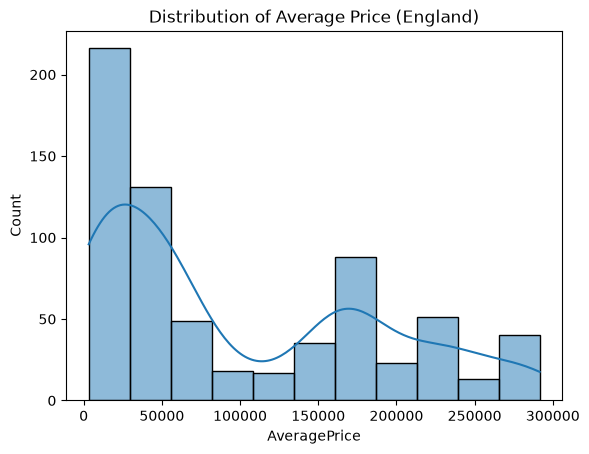

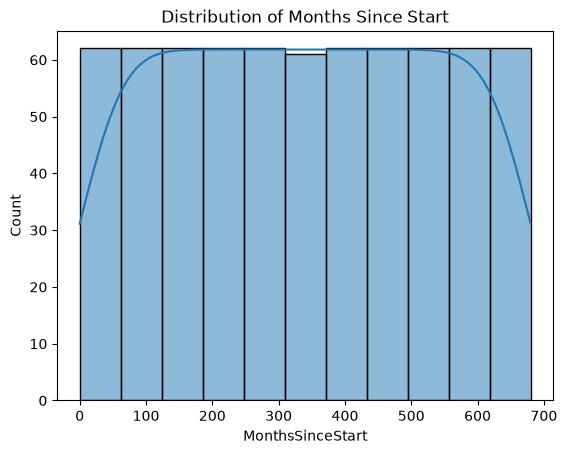

In [16]:
sns.histplot(df_england['AveragePrice'], kde=True)
plt.title('Distribution of Average Price (England)')
plt.show()

sns.histplot(df_england['MonthsSinceStart'], kde=True)
plt.title('Distribution of Months Since Start')
plt.show()

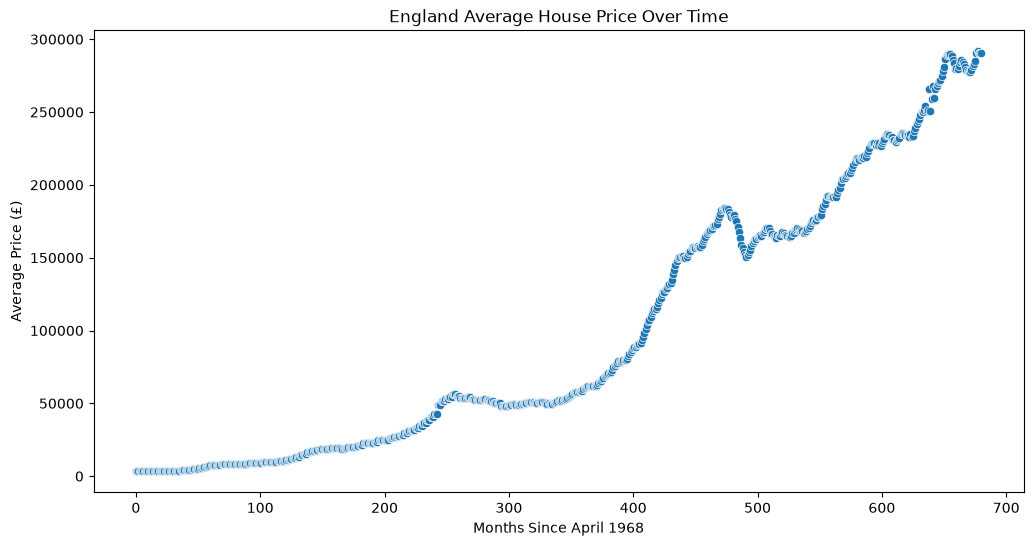

In [17]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='MonthsSinceStart', y='AveragePrice', data=df_england)
plt.title('England Average House Price Over Time')
plt.xlabel('Months Since April 1968')
plt.ylabel('Average Price (£)')
plt.show()

In [18]:
df_england[['MonthsSinceStart', 'AveragePrice']].corr()

,MonthsSinceStart,AveragePrice
MonthsSinceStart,1.00000,0.95327
AveragePrice,0.95327,1.00000


In [19]:
max_date = df_england['Date'].max()
cutoff_date = max_date - pd.DateOffset(years=15)

df_recent = df_england[df_england['Date'] >= cutoff_date].copy()
df_recent.shape

(181, 55)

In [20]:
df_recent = df_recent.sort_values('Date').reset_index(drop=True)

start_date_recent = df_recent['Date'].min()
df_recent['MonthsSinceStart'] = (
    (df_recent['Date'].dt.year - start_date_recent.year) * 12 +
    (df_recent['Date'].dt.month - start_date_recent.month)
)

df_recent[['Date', 'MonthsSinceStart', 'AveragePrice']].head()

,Date,MonthsSinceStart,AveragePrice
0,2009-12-01,0,164408
1,2010-01-01,1,164711
2,2010-02-01,2,165457
3,2010-03-01,3,165002
4,2010-04-01,4,166919


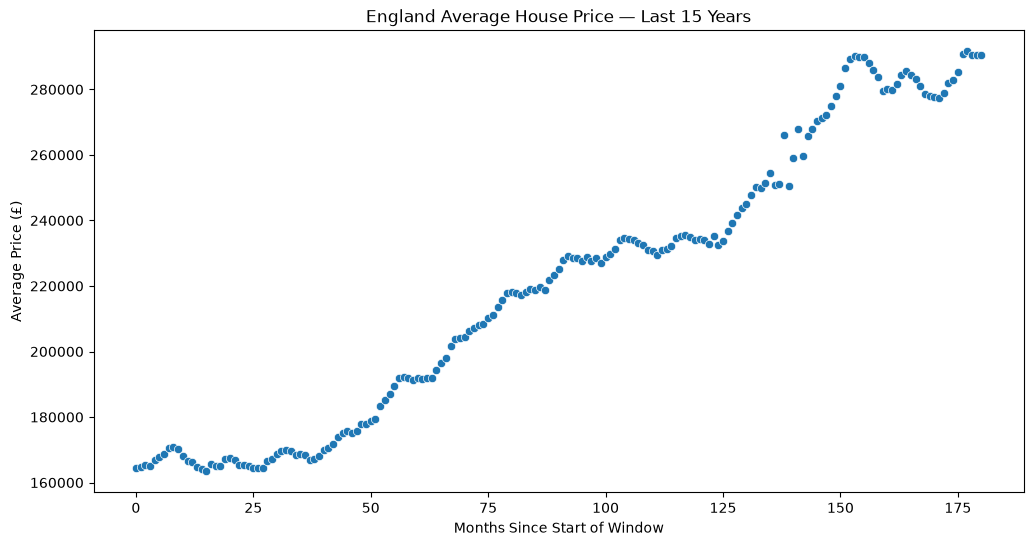

,MonthsSinceStart,AveragePrice
MonthsSinceStart,1.000000,0.983108
AveragePrice,0.983108,1.000000


In [21]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='MonthsSinceStart', y='AveragePrice', data=df_recent)
plt.title('England Average House Price — Last 15 Years')
plt.xlabel('Months Since Start of Window')
plt.ylabel('Average Price (£)')
plt.show()

df_recent[['MonthsSinceStart', 'AveragePrice']].corr()

In [22]:
X = df_recent[['MonthsSinceStart']]
y = df_recent['AveragePrice']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(144, 1) (37, 1) (144,) (37,)


In [ ]:
split_index = int(len(df_recent) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)